In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)

from xgboost import XGBRegressor

In [2]:
california = fetch_california_housing()
x_full = pd.DataFrame(california.data, columns=california.feature_names)
y_full = california.target

features = ['MedInc','HouseAge','AveRooms','AveBedrms']
x_selected = x_full[features]

x_train,x_test,y_train,y_test=train_test_split(
    x_selected,y_full,test_size=0.2,random_state=42
)

In [3]:
print("---Task 1---")
tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model.fit(x_train,y_train)
tree_preds = tree_model.predict(x_test)
tree_r2 = r2_score(y_test,tree_preds)
print(f"R2 Score (Decision Tree): {tree_r2:.4}\n")

---Task 1---
R2 Score (Decision Tree): 0.5075



In [7]:
print("---Task 2---")
forest_model = RandomForestRegressor(n_estimators=100,random_state=42)
forest_model.fit(x_train,y_train)
forest_preds = forest_model.predict(x_test)
forest_r2 = r2_score(y_test, forest_preds)
results_table = pd.DataFrame({
    "Model":["DecisionTree", "RandomForest"],
    "R2_Score":[tree_r2, forest_r2]
})
print("Таблиця порівняння Завдання 2:")
print(results_table.to_string(index=False), "\n")

---Task 2---
Таблиця порівняння Завдання 2:
       Model  R2_Score
DecisionTree  0.507482
RandomForest  0.587887 



In [12]:
print("---Task 3---")

xgb_model = XGBRegressor(n_estimators=200,learning_rate=0.1,max_depth=5,random_state=42)
xgb_model.fit(x_train,y_train)
xgb_preds = xgb_model.predict(x_test)
xgb_r2= r2_score(y_test,xgb_preds)

results_table.loc[2] = ["XGBBoost",xgb_r2]
print("Оновлена таблиця порівняння:")
print(results_table.to_string(index=False), "\n")

---Task 3---
Оновлена таблиця порівняння:
       Model  R2_Score
DecisionTree  0.507482
RandomForest  0.587887
    XGBBoost  0.599275 



---Task 4---
Метрики класифікації:
Accuracy:  0.8270
Precision: 0.8266
Recall:    0.8250
F1 Score:  0.8258

Матриця помилок (Confusion Matrix) у вигляді тексту:
[[1722  355]
 [ 359 1692]]


c:\Users\maxim\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


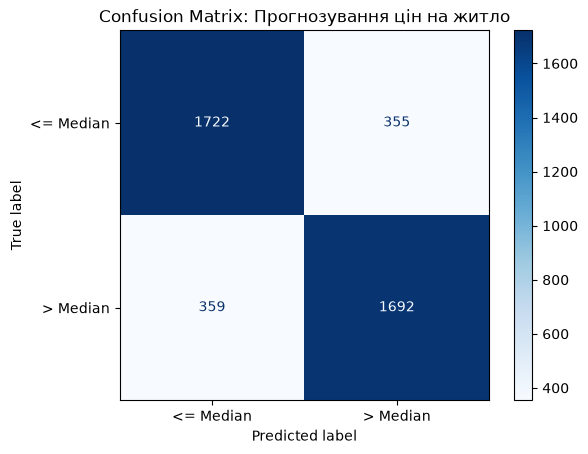

In [15]:
print("---Task 4---")

median_price = np.median(y_full)

y_class = (y_full > median_price).astype(int)

x_train_cls,x_test_cls,y_train_cls,y_test_cls = train_test_split(
    x_full,y_class,test_size=0.2,random_state=42
)

log_reg = LogisticRegression(max_iter=1000,random_state=42)
log_reg.fit(x_train_cls,y_train_cls)

y_pred_cls = log_reg.predict(x_test_cls)

accuracy = accuracy_score(y_test_cls,y_pred_cls)
precision = precision_score(y_test_cls,y_pred_cls)
recall = recall_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls,y_pred_cls)

print("Метрики класифікації:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}\n")

cm = confusion_matrix(y_test_cls,y_pred_cls)
print("Матриця помилок (Confusion Matrix) у вигляді тексту:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<= Median", "> Median"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Прогнозування цін на житло")
plt.show()